<a href="https://colab.research.google.com/github/GMISSAGLIA/GM_PyLab/blob/Main/Hyperparameters_Tuning_with_Optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style = "color:blue;"> Hyperparameter Tuning Part 2: Optuna</h1>

<br/>
<sectiom style="font-family: Arial; font-size: 14px;text-align: justify;">
<p style="text-align: justify;">
 This is the second part of our exploration into hyperparameter tuning for machine learning models. In the previous notebook, we covered traditional methods like Grid Search and Randomized Search using Scikit-learn.

In this notebook, we dive into Optuna, a next-generation hyperparameter optimization framework. Optuna offers several advantages:
<ul>
<li>Highly flexible and intuitive API: Easy to define search spaces and objective functions.</li>
<li>State-of-the-art optimization algorithms: Includes algorithms like Tree-structured Parzen Estimator (TPE) for efficient exploration of the search space. </li>
<li>Excellent for parallelization and distributed tuning: Easily scales to run trials across multiple cores or machines. </li>
<li>Great visualization tools: Provides built-in plots to understand the optimization process and results. </li>
<li>Framework-agnostic: Works seamlessly with various machine learning libraries such as PyTorch, TensorFlow, Keras, and scikit-learn. </li>
</ul>
For flexibility, modern algorithms, and good visualization, especially for deep learning: Optuna is a fantastic choice. It's often recommended as a great all-around solution.
</br>
As in the first part, we will use a neural network model and the <strong><a href="https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database?resource=download">Pima Indian Diabetes dataset</a> </strong> which contains diagnostic measurements of female patients of Pima Indian heritage. The objective is to predict whether or not a patient has diabetes based on certain medical predictor variables.

As a rule of thumb, when working with small and non-complex datasets, you would avoid models with a large number of parameters to reduce the risk of overfitting. Adding more layers and increasing the number of neurons per layer enhances the model's capacity, but it also increases the number of parameters and, consequently, the risk of overfitting. Given that we have a simple tabular dataset, we will follow this rule and define a consistent search space for the hyperparameter tuning process.
</p>

</section>


<section>
    <h2 style = "color:blue;">Recap on Performance Metrics</h2>
    <p>
        Before we begin, here’s a brief recap of the performance metrics — the indicators we’ll use to compare different models and parameter choices.
        When working with a binary target variable, you typically start by computing the confusion matrix, which compares the predicted values against the true values. It includes:
    </p>
    <ul>
        <li><strong>True Positives (TP)</strong>: predicted 1, and the true label is also 1</li>
        <li><strong>False Positives (FP)</strong>: predicted 1, but the true label is 0</li>
        <li><strong>True Negatives (TN)</strong>: predicted 0, and the true label is also 0</li>
        <li><strong>False Negatives (FN)</strong>: predicted 0, but the true label is 1</li>
    </ul>
    <p>
        From these values, we can derive the following core performance metrics:
    </p>
    <ul>
        <li><strong>Precision</strong>: TP / (TP + FP) — the proportion of positive predictions that were correct</li>
        <li><strong>Recall (Sensitivity)</strong>: TP / (TP + FN) — the proportion of actual positives that were correctly predicted</li>
        <li><strong>Specificity</strong>: TN / (TN + FP) — the proportion of actual negatives that were correctly predicted</li>
        <li><strong>Accuracy</strong>: (TP + TN) / (TP + TN + FP + FN) — the overall proportion of correct predictions</li>
        <li><strong>F1 Score</strong>: 2 × (Precision × Recall) / (Precision + Recall) — the harmonic mean of precision and recall, useful when the classes are imbalanced</li>
        <li><strong>AUC (Area Under the ROC Curve) </strong>:Measures the model’s ability to rank positive instances higher than negative ones across all thresholds.</li>
    </ul>
</section>



<p style = "font-family: 'Arial', sans-serif; font-size: 14px; text-align: justify;">Unlike the first part where we used AUC, here we will use the F1 Score as our metric. Anyway, here is a synthetic table on performance metrics that will help you choose the right metric for your model.</p>

<table style="font-family: 'Arial', sans-serif; border-collapse: collapse; width: 100%; margin: 20px 0; table-layout: fixed;">
  <thead>
    <tr>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 15%; word-wrap: break-word;">Metric</th>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 25%; word-wrap: break-word;">Implementation</th>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 25%; word-wrap: break-word;">Best For</th>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 35%; word-wrap: break-word;">Example Applications</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Accuracy</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['accuracy']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Balanced datasets with equally important classes</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • General balanced classification<br>
        • Image classification<br>
        • Document categorization
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Precision</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['precision']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Scenarios where false positives are costly</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Spam detection<br>
        • Medical diagnosis<br>
        • Fraud detection
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Recall</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['recall']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Scenarios where false negatives are costly</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Disease detection<br>
        • Security threat identification<br>
        • Failure prediction
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">F1-score</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['f1_score']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Cases requiring balance between precision and recall</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Information retrieval<br>
        • Named entity recognition<br>
        • Imbalanced datasets where both error types matter
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">AUC</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['AUC']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Ranking problems and imbalanced datasets</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Credit scoring<br>
        • Churn prediction<br>
        • Recommendation systems
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;">Specificity</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;"><code>metrics=[tf.keras.metrics.SpecificityAtSensitivity(0.5)]</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;">Cases where true negatives are important</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;">
        • Medical screening<br>
        • Security systems<br>
        • Quality control
      </td>
    </tr>
    <tr>

In [ ]:
# Install necessary libraries
%pip install optuna scikeras pandasql matplotlib seaborn imblearn keras-tuner kaleido
%pip install --upgrade plotly>=6.1.1

In [6]:
# === Standard Libraries ===
import os
import time
import json
from pathlib import Path
from datetime import datetime
from collections import Counter
from typing import Union, Sequence, Tuple, Dict, Any, Optional, Callable
import shutil
import warnings
import pickle

# === Data Handling ===
import numpy as np
import pandas as pd
import pandasql as ps
from pandasql import sqldf

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# === Scikit-learn ===
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report,  roc_auc_score,  confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve)

# === Imbalanced Data Handling ===
from imblearn.over_sampling import SMOTE, SMOTENC, ADASYN

# === Model Wrappers ===
from scikeras.wrappers import KerasClassifier

# === TensorFlow / Keras ===
import tensorflow as tf
import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.regularizers import l1, l2, l1_l2, OrthogonalRegularizer
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, RandomNormal, RandomUniform
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras import Input
from tensorflow.python.framework.ops import EagerTensor

# === Hyperparameter Optimization ===
import optuna
from optuna.samplers import TPESampler
import keras_tuner as kt

# === Model Persistence ===
import joblib

# === SHAP (Explainability) ===
import shap

# === GUI (Tkinter) ===
import tkinter as tk
from tkinter import Tk, filedialog
from tkinter.filedialog import askopenfilename

warnings.filterwarnings('ignore')

In [7]:
start_time = time.time()

In [8]:
# before we start we define some utility functions we will apply in the next steps
def split_dataset(
    X: np.ndarray,
    y:np.ndarray,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
    stratify: bool = True,
    random_state: int = 42
) -> Tuple[np.ndarray,np.ndarray, np.ndarray,np.ndarray, np.ndarray, np.ndarray]:
    """
    Split a dataset into training, validation, and test sets.
     Args:
        X: Features dataset
        y: Target values
        train_size: Proportion of the dataset to include in the train split (default: 0.6)
        val_size: Proportion of the dataset to include in the validation split (default: 0.2)
        test_size: Proportion of the dataset to include in the test split (default: 0.2)
        stratify: Whether to preserve the class distribution in each split (default: True)
        random_state: Controls the shuffling applied to the data (default the evergreen 42)

    Returns:
        A tuple containing (X_train, X_val, X_test, y_train, y_val, y_test)

    Raises:
        ValueError: If the sum of train_size, val_size, and test_size is not 1.0
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Proportions must sum to 1.0"
    if len(X) < 20:
        raise ValueError("Dataset too small to split reliably.")

    stratify_y = y if stratify else None

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, stratify=stratify_y, random_state=random_state
    )

    val_relative = val_size / (train_size + val_size)
     # Determine stratification for second split

    stratify_y = y_trainval if stratify else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_relative, stratify=stratify_y, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def fit_scaler(X: pd.DataFrame, output_prefix: str = "split") -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(X)
    os.makedirs("data_splits", exist_ok=True)
    joblib.dump(scaler, f"data_splits/{output_prefix}_scaler.pkl")
    return scaler

def apply_scaler(X: pd.DataFrame, output_prefix: str = "split") -> pd.DataFrame:
    scaler_path = f"data_splits/{output_prefix}_scaler.pkl"
    if not os.path.exists(scaler_path):
        raise FileNotFoundError(f"Scaler file not found: {scaler_path}")
    scaler = joblib.load(scaler_path)
    return pd.DataFrame(scaler.transform(X), columns=X.columns)

def balance_data(
    X: pd.DataFrame,
    y: pd.Series,
    method: str = "NONE",
    random_state: int = 42,
    categorical_features: Optional[list] = None
) -> Tuple[pd.DataFrame, pd.Series]:
    print("Class distribution before balancing:", Counter(y))
    if method == "SMOTENC":
        if categorical_features is None:
            raise ValueError("categorical_features must be provided for SMOTENC")
        sampler = SMOTENC(categorical_features=categorical_features, random_state=random_state)
    elif method == "ADASYN":
        sampler = ADASYN(random_state=random_state)
    elif method == "SMOTE":
        sampler = SMOTE(random_state=random_state)
    else:
        return X, y
    X_bal, y_bal = sampler.fit_resample(X, y)
    print("Class distribution after balancing:", Counter(y_bal))
    return X_bal, y_bal

def plot_split_distribution(
    y_train: pd.Series,
    y_val: pd.Series,
    y_test: pd.Series
) -> None:
    df = pd.DataFrame({
        'Split': ['Train'] * len(y_train) + ['Val'] * len(y_val) + ['Test'] * len(y_test),
        'Target': pd.concat([
            y_train.reset_index(drop=True),
            y_val.reset_index(drop=True),
            y_test.reset_index(drop=True)
        ])
    })
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Split', hue='Target')
    plt.title('Class Distribution Across Splits')
    plt.tight_layout()
    plt.show()

def load_split_csv(output_prefix: str = "split") -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    X_train = pd.read_csv(f"data_splits/{output_prefix}_X_train.csv")
    X_val = pd.read_csv(f"data_splits/{output_prefix}_X_val.csv")
    X_test = pd.read_csv(f"data_splits/{output_prefix}_X_test.csv")
    y_train = pd.read_csv(f"data_splits/{output_prefix}_y_train.csv").squeeze()
    y_val = pd.read_csv(f"data_splits/{output_prefix}_y_val.csv").squeeze()
    y_test = pd.read_csv(f"data_splits/{output_prefix}_y_test.csv").squeeze()
    return X_train, X_val, X_test, y_train, y_val, y_test


def SPECIFICITY(y_true: Union[Sequence[int], np.ndarray],
                y_pred: Union[Sequence[int], np.ndarray]) -> float:
    """
    Computes the specificity (true negative rate) for binary classification.
    As Precision measures the proportion of positives correctly identified
    Specificity  does the same for negatives measuring the proportion of actual negatives correctly identified.
    - Specificity = TN / (TN + FP)
    Parameters:
    - y_true: Ground truth binary labels (0 or 1)
    - y_pred: Predicted binary labels (0 or 1)
    Returns:
    - Specificity as a float between 0 and 1
    """
    # Unpack confusion matrix into true negatives, false positives, false negative, true positive.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Compute specificity, adding a small epsilon to avoid division by zero
    return tn / (tn + fp + K.epsilon())

def bayes_recalibrate(p_model, pi_real, pi_train):
    odds = p_model / (1 - p_model)
    correction = (pi_real / (1 - pi_real)) / (pi_train / (1 - pi_train))
    corrected_odds = odds * correction
    return corrected_odds / (1 + corrected_odds)

In [9]:
def load_data(url:str = "https://raw.githubusercontent.com/GMISSAGLIA/GM_PyLab/refs/heads/Main/diabetes.csv", load_from_git: bool = False) -> pd.DataFrame:
    """
    Load the Pima Indians Diabetes dataset either from GitHub or through a file dialog.
    Args:
        load_from_git (bool): If True, load data from GitHub.
        If False, open a file dialog.
    Returns:
        pd.DataFrame: The loaded diabetes dataset.
    """
    if load_from_git:
        # Load the Pima Indians Diabetes dataset from GitHub repository
        column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
        return pd.read_csv(url, names=column_names, skiprows=1)  # Skip the header row
    else:
        # Load data through file dialog
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(filetypes=[("CSV files", "*.csv")])
        return pd.read_csv(file_path)


In [10]:
# Load the dataset
df = load_data(load_from_git=True)
# Rename the 'Outcome' column to 'Target'
df.rename(columns={"Outcome": "Target"}, inplace=True)
# Extract features and target variable
X = df.drop("Target", axis=1) #Features
y = df["Target"] #Target
# Display the first few rows of the dataframe
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Target
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


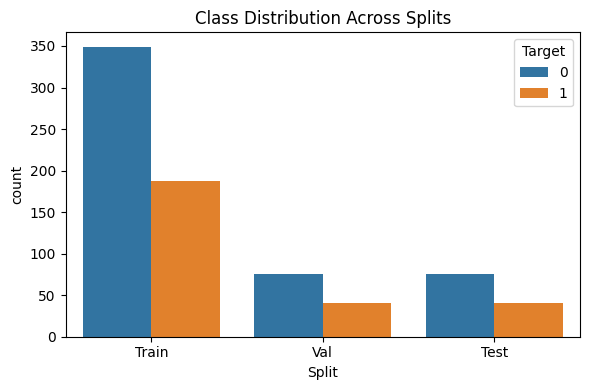

In [12]:
"""
We split the full dataset into training, validation, and test sets:
- Training: used to explore and tune hyperparameters
- Validation: used to evaluate hyperparameter performance during tuning
- Test: used to evaluate the final selected model (kept aside until the end)
"""
split_params = {
    "train_size": 0.7,
    "val_size": 0.15,
    "test_size": 0.15,
    "stratify": True,
    "random_state": 42
}
# Split the dataset into training, validation and test sets
# Validation is for check the Hyperparameter tuning
# Test is for the final validation of the selected model
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X=X,
    y=y,
    **split_params
)

plot_split_distribution(y_train, y_val, y_test)

The dataset was split into three distinct parts:

*   **Training set (`X_train`, `y_train`)**: This portion of the data is used to train the machine learning model during the hyperparameter tuning process. The model learns from this data.
*   **Validation set (`X_val`, `y_val`)**: This set is used to evaluate the performance of the model with different sets of hyperparameters *during* the tuning process. Optuna uses the model's performance on this set (specifically the AUC calculated in the `objective` function) to determine which hyperparameters are best. It helps in selecting the best model configuration without using the final test set.
*   **Test set (`X_test`, `y_test`)**: This dataset is kept entirely separate and is **only** used for the final, unbiased evaluation of the *best* model after the hyperparameter tuning is complete. It provides an estimate of how the model will perform on unseen data.

The `validation_split` parameter used within the `KerasClassifier` in the `objective` function is for an *internal* validation split during the Keras model's training on the `X_train` data, used for monitoring and early stopping, and is separate from the main `X_val`, `y_val` used for Optuna's trial evaluation.

In [13]:
# Define the neural network model
def create_model(
    optimizer='adam',              # Optimizer to use (default: Adam)
    init='glorot_uniform',         # Weight initialization method
    dropout_rate=0.0,              # Dropout rate for regularization
    l2_reg=0.0,
    learning_rate=0.001,
    batch_norm=False,
    input_shape=(8,),              # Shape of the input layer
    n_layers=1,
    units_1=8,
    units_2=6,
    units_3=4):

    model = tf.keras.Sequential() # Create a sequential Keras model
    model.add(tf.keras.layers.Input(shape=(8,))) # Add the input layer, specifying the shape of the input data (8 features)

    # Add hidden layers based on the 'n_layers' parameter
    for i in range(n_layers):
        # Select the number of units for the current layer
        units = [units_1, units_2, units_3][i]
        # Add a Dense (fully connected) layer with ReLU activation
        model.add(tf.keras.layers.Dense(units, activation='relu',
                               # Apply L2 regularization if specified
                               kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        # Add Batch Normalization if specified
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        # Add Dropout if the rate is greater than 0
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    # Add the output layer with a single unit and sigmoid activation
    # for binary classification
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Compile the model with Adam optimizer, binary crossentropy loss,
    # and performace metrics
    model.compile(loss='binary_crossentropy', optimizer=optimizer,
                   metrics = [tf.keras.metrics.Accuracy(name='accuracy'),
                              tf.keras.metrics.Precision(name='precision'),
                              tf.keras.metrics.Recall(name='recall'),
                              tf.keras.metrics.AUC(name='AUC'),
                              tf.keras.metrics.F1Score(name='f1_score')])

    # Return the compiled model
    return model

In [14]:
def create_objective(
    X_train: Union[pd.DataFrame, np.ndarray],
    y_train: Union[pd.Series, np.ndarray],
    X_val: Union[pd.DataFrame, np.ndarray],
    y_val: Union[pd.Series, np.ndarray],
    create_model: Callable ) -> Callable[[optuna.trial.Trial], float]:
    """
    Creates an Optuna objective function with data and model builder injected.
    """
    def objective(trial: optuna.trial.Trial) -> float:
            # === Hyperparameter Suggestions ===
            n_layers = trial.suggest_int("n_layers", 1, 2)
            units_1 = trial.suggest_categorical("units_1", [8, 6, 4])
            units_2 = trial.suggest_categorical("units_2", [6, 5, 4]) if n_layers >= 2 else None
            units_3 = trial.suggest_categorical("units_3", [6, 5, 4]) if n_layers >= 3 else None
            learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
            batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
            dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
            l2_reg = trial.suggest_float("l2_reg", 0.0, 0.1)
            batch_norm = trial.suggest_categorical("batch_norm", [True, False])
            optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
            epochs = trial.suggest_int("epochs", 10, 50)
            # Add suggestion for classification threshold
            classification_threshold = trial.suggest_float("classification_threshold", 0.01, 0.99)

            # === Optimizer Selection ===
            if optimizer_name == "Adam":
                optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
            elif optimizer_name == "RMSprop":
                optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
            else:
                optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

            # === Keras Classifier ===
            model = KerasClassifier(
                model=create_model,
                model__n_layers=n_layers,
                model__units_1=units_1,
                model__units_2=units_2,
                model__units_3=units_3,
                model__dropout_rate=dropout_rate,
                model__l2_reg=l2_reg,
                model__batch_norm=batch_norm,
                model__learning_rate=learning_rate,
                optimizer=optimizer,
                batch_size=batch_size,
                epochs=epochs,
                callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',
                patience=5, restore_best_weights=True)],
                validation_split=0.2,
                verbose=0
            )

            # === Pipeline with Scaler ===
            pipeline = Pipeline([('scaler', StandardScaler()),('nn', model)])
            pipeline.fit(X_train, y_train)

            X_val_scaled = pipeline.named_steps['scaler'].transform(X_val)
            val_proba = pipeline.named_steps['nn'].predict_proba(X_val_scaled)[:, 1]

            # Use the suggested classification threshold
            val_pred = (val_proba > classification_threshold).astype(int)

            # Calculate metrics
            auc = roc_auc_score(y_val, val_proba)
            accuracy = accuracy_score(y_val, val_pred)
            precision = precision_score(y_val, val_pred)
            recall = recall_score(y_val, val_pred)
            f1 = f1_score(y_val, val_pred)
            specificity = SPECIFICITY(y_val, val_pred)


            trial.set_user_attr("architecture", f"{n_layers}_{units_1}_{units_2}_{units_3}")
            trial.set_user_attr("optimizer", optimizer_name)
            trial.set_user_attr("AUC", auc)
            trial.set_user_attr("f1_score", f1)
            trial.set_user_attr("accuracy", accuracy)
            trial.set_user_attr("precision", precision)
            trial.set_user_attr("recall", recall)
            trial.set_user_attr("specificity", specificity)
            trial.set_user_attr("classification_threshold", classification_threshold)

            return f1


    return objective


def print_callback(study: optuna.Study, trial: optuna.trial.FrozenTrial) -> None:
    print(f"Trial {trial.number}: AUC = {trial.value:.4f} | Best: {study.best_value:.4f}")

Besides the objective value and the hyperparameters (`trial.params`), here are some other pieces of information you can retrieve from each individual trial (`optuna.trial.FrozenTrial`) object:

*   **`trial.number`**: The unique identification number of the trial within the study.
*   **`trial.state`**: The current state of the trial (e.g., `COMPLETE`, `PRUNED`, `FAIL`).
*   **`trial.value`**: The objective value obtained in this trial.
*   **`trial.datetime_start`**: The timestamp when the trial started.
*   **`trial.datetime_complete`**: The timestamp when the trial completed.
*   **`trial.duration`**: The time taken to complete the trial (`datetime_complete` - `datetime_start`).
*   **`trial.params`**: A dictionary of the hyperparameter values sampled for this trial.
*   **`trial.user_attrs`**: A dictionary of user-defined attributes. This is where we stored the additional metrics (Accuracy, Precision, Recall, F1 Score) and the architecture information. You can store any custom information here that you calculate within your objective function.
*   **`trial.system_attrs`**: A dictionary of system-defined attributes, often used by Optuna internally.

By accessing these attributes, you can get a comprehensive view of each trial's execution and results beyond just the objective value and parameters. The `user_attrs` are particularly flexible for storing any custom metrics or metadata relevant to your specific objective function.

In [15]:
def hyperparameters_tuning(X_train, y_train, X_val, y_val, create_model):
    # Create objective with data injection
    objective_fn = create_objective(X_train, y_train, X_val, y_val, create_model)
    # Create and run Optuna study
    study = optuna.create_study(
        study_name="Optuna_HP",
        direction="maximize",
        load_if_exists=True,
        sampler=TPESampler(seed=42)
    )

    study.optimize(
        objective_fn,
        n_trials=120,
        callbacks=[print_callback],
        show_progress_bar=True
    )

    # Generate and display the optimization history
    try:
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()
    except Exception as e:
        print(f"Could not generate optimization history plot: {e}")

    return study

In [16]:
def get_trials_dataframe(study: optuna.Study) -> pd.DataFrame:
    """
    Retrieves the structure and parameters of all completed trials in an Optuna study
    and returns them as a pandas DataFrame.

    Args:
        study (optuna.Study): The Optuna study object.

    Returns:
        pd.DataFrame: A DataFrame where each row represents a trial
                      and columns are trial attributes and hyperparameters.
    """
    if not study.trials:
        print("No trials found in the study.")
        return pd.DataFrame()

    # Filter out trials that were not completed successfully (e.g., pruned, failed)
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

    if not completed_trials:
        print("No completed trials found in the study.")
        return pd.DataFrame()

    # Extract trial info and parameters
    trial_data = []
    for trial in completed_trials:
        data = {
            "Trial Number": trial.number,
            "Value": trial.value,
            "State": trial.state.name,
            "Duration": trial.duration,
            "Start Time": trial.datetime_start,
            "End Time": trial.datetime_complete,
        }
        # Add hyperparameters as columns
        data.update(trial.params)
        # Add user attributes as columns (e.g., architecture, optimizer)
        data.update(trial.user_attrs)
        trial_data.append(data)

    df = pd.DataFrame(trial_data)

    # we reorder columns to put trial info first
    cols = ["Trial Number", "Value", "State", "Duration", "Start Time", "End Time"]
    param_cols = [col for col in df.columns if col not in cols]
    df = df[cols + param_cols]

    return df


In [ ]:
# We run the Optuna hyperparameters tuning process
OptunaStudy = hyperparameters_tuning(X_train, y_train, X_val, y_val, create_model)

In [18]:
# Save as pickle
with open("OptunaStudy.pkl", "wb") as f:
    pickle.dump(OptunaStudy, f)

print("Saved Optuna study to study.pkl")

Saved Optuna study to study.pkl


In [27]:
bt = OptunaStudy.best_trial
df_trials = get_trials_dataframe(OptunaStudy)
df_best_trial= df_trials[df_trials['Trial Number'] == bt.number] #Retrive the best trial from the trials dataframe

# Add the 'tipo' column
df_best_trial['tipo'] = "Best Trial"

# Reorder columns to make 'tipo' the first column
cols = ['tipo'] + [col for col in df_best_trial.columns if col != 'tipo']
df_best_trial = df_best_trial[cols]

display(df_trials)
display(df_best_trial)

,Trial Number,Value,State,Duration,Start Time,End Time,n_layers,units_1,learning_rate,batch_size,...,epochs,classification_threshold,architecture,AUC,f1_score,accuracy,precision,recall,specificity,units_2
0,0,0.496644,COMPLETE,0 days 00:00:09.740582,2025-08-03 21:08:34.275686,2025-08-03 21:08:44.016268,1,8,0.000294,64,...,17,0.308157,1_8_None_None,0.439675,0.496644,0.353448,0.342593,0.902439,0.053333,NaN
1,1,0.640777,COMPLETE,0 days 00:00:32.475605,2025-08-03 21:08:44.023703,2025-08-03 21:09:16.499308,2,4,0.002335,16,...,43,0.308521,2_4_4_None,0.765691,0.640777,0.681034,0.532258,0.804878,0.613333,4.0
2,2,0.000000,COMPLETE,0 days 00:00:15.552289,2025-08-03 21:09:16.505891,2025-08-03 21:09:32.058180,1,8,0.003059,32,...,48,0.886931,1_8_None_None,0.755122,0.000000,0.646552,0.000000,0.000000,1.000000,NaN
3,3,0.000000,COMPLETE,0 days 00:00:09.601821,2025-08-03 21:09:32.062705,2025-08-03 21:09:41.664526,2,8,0.000652,16,...,10,0.809152,2_8_4_None,0.468293,0.000000,0.646552,0.000000,0.000000,1.000000,4.0
4,4,0.000000,COMPLETE,0 days 00:00:15.636222,2025-08-03 21:09:41.669410,2025-08-03 21:09:57.305632,2,6,0.007411,16,...,41,0.560052,2_6_4_None,0.804878,0.000000,0.646552,0.000000,0.000000,1.000000,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,115,0.564885,COMPLETE,0 days 00:00:13.980303,2025-08-03 21:32:47.791289,2025-08-03 21:33:01.771592,2,4,0.041145,16,...,27,0.175026,2_4_5_None,0.751707,0.564885,0.508621,0.411111,0.902439,0.293333,5.0
116,116,0.681818,COMPLETE,0 days 00:00:10.136551,2025-08-03 21:33:01.778184,2025-08-03 21:33:11.914735,1,8,0.054303,32,...,24,0.351734,1_8_None_None,0.814634,0.681818,0.758621,0.638298,0.731707,0.773333,NaN
117,117,0.638298,COMPLETE,0 days 00:00:09.878545,2025-08-03 21:33:11.920099,2025-08-03 21:33:21.798644,1,8,0.054469,32,...,24,0.348624,1_8_None_None,0.763252,0.638298,0.706897,0.566038,0.731707,0.693333,NaN
118,118,0.673913,COMPLETE,0 days 00:00:12.029279,2025-08-03 21:33:21.803378,2025-08-03 21:33:33.832657,1,8,0.070800,16,...,26,0.390536,1_8_None_None,0.801626,0.673913,0.741379,0.607843,0.756098,0.733333,NaN


,tipo,Trial Number,Value,State,Duration,Start Time,End Time,n_layers,units_1,learning_rate,...,epochs,classification_threshold,architecture,AUC,f1_score,accuracy,precision,recall,specificity,units_2
88,Best Trial,88,0.712871,COMPLETE,0 days 00:00:16.592935,2025-08-03 21:27:01.673595,2025-08-03 21:27:18.266530,1,8,0.014801,...,36,0.262365,1_8_None_None,0.822114,0.712871,0.75,0.6,0.878049,0.68,NaN


In [20]:
print(f"\nBest trial: {bt.number}")
print(f"Best Value: {OptunaStudy.best_value:.4f}")
print("Best parameters:")
for key, value in OptunaStudy.best_params.items():
    print(f"  {key}: {value}")

for key, value in bt.user_attrs.items():
    print(f"  {key}: {value}")

best_params_df = pd.DataFrame([bt.params])
# Add the study name as a new column
best_params_df['Study Name'] = OptunaStudy.study_name

# Display the DataFrame
display(best_params_df)



Best trial: 88
Best Value: 0.7129
Best parameters:
  n_layers: 1
  units_1: 8
  learning_rate: 0.014801104269243982
  batch_size: 32
  dropout_rate: 0.12139192663177019
  l2_reg: 0.07568938755355745
  batch_norm: True
  optimizer: Adam
  epochs: 36
  classification_threshold: 0.2623646913443034
  architecture: 1_8_None_None
  optimizer: Adam
  AUC: 0.8221138211382114
  f1_score: 0.7128712871287128
  accuracy: 0.75
  precision: 0.6
  recall: 0.8780487804878049
  specificity: 0.6799999990933334
  classification_threshold: 0.2623646913443034


,n_layers,units_1,learning_rate,batch_size,dropout_rate,l2_reg,batch_norm,optimizer,epochs,classification_threshold,Study Name
0,1,8,0.014801,32,0.121392,0.075689,True,Adam,36,0.262365,Optuna_HP


In [21]:
def EvaluateModel(
    y_pred: Union[np.ndarray, list],
    y_proba: Union[np.ndarray, list],
    y_test: Union[np.ndarray, list],
    model_name: str = "Model"
) -> pd.DataFrame:
    """
    Evaluate a binary classification model by calculating performance metrics,
    plotting the ROC curve and confusion matrix, and returning a metrics summary.

    Args:
        y_pred (array-like): Binary predicted labels (0 or 1).
        y_proba (array-like): Predicted probabilities for the positive class.
        y_test (array-like): True binary labels.
        model_name (str): Name or label of the model (included in the result).

    Returns:
        pd.DataFrame: A one-row DataFrame with evaluation metrics and the model name.
    """

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": SPECIFICITY(y_test, y_pred),  # funzione definita a parte
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

    print(f"\n📊 Evaluation metrics for '{model_name}':")
    for name, value in metrics.items():
        if name != "Model":
            print(f"{name}: {value:.3f}")
    print("\n\n")
    # ROC Curve Plot
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label="ROC curve")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Add some vertical space in the output
    print("\n\n")

    # Confusion Matrix Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame([metrics])

In [22]:
def summarize_layers(model: Union[Model, object], model_name:str = 'model') -> pd.DataFrame:
    """
    Extracts a detailed layer-by-layer summary from a compiled Keras model
    and returns it as a pandas DataFrame.
    Parameters:
        model: A compiled and built Keras model (instance of keras.Model)
    Returns:
        A pandas DataFrame containing:
            - Layer name
            - Layer type
            - Output shape
            - Activation function
            - Units (for Dense) or filters (for Conv)
            - Trainable status
            - Number of parameters
    """
    summary = []

    # 🔁 Loop through all layers in the model
    for layer in model.layers:
        # Get the layer configuration dictionary
        config = layer.get_config()

        # Collect useful information for each layer
        layer_info = {
            "Model Name": model_name,
            "Layer Name": layer.name,
            "Layer Type": layer.__class__.__name__,
            "Output Shape": layer.output_shape if hasattr(layer, 'output_shape') else 'N/A',
            "Activation": config.get("activation", "N/A"),  # Only available in activatable layers
            "Units/Filters": config.get("units", config.get("filters", "N/A")),  # Dense or Conv
            "Params": layer.count_params(),
            "Trainable": layer.trainable
        }
        if isinstance(layer, tf.keras.layers.Dropout):
           layer_info["Dropout Rate"] = layer.rate
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer_info["Momentum"] = layer.momentum
            layer_info["Epsilon"] = layer.epsilon

        # Append the layer info to the summary list
        summary.append(layer_info)

    # 📊 Convert the list of dictionaries to a pandas DataFrame and return it
    return pd.DataFrame(summary)

In [23]:
def summarize_model(model, name='Model'):
    """
    Extracts summary info from a compiled Keras model:
    - Counts the number of Dense layers
    - Sums the total number of neurons across Dense layers
    - Retrieves total, trainable, and non-trainable parameters
    Returns the info as a one-row pandas DataFrame.
    """
    # ✅ Ensure the model is built before accessing layer properties like shapes or units
    if not model.built:
        try:
            model.build(input_shape=(None, 8))  # Build with a default input shape if needed
        except:
            pass  # Ignore if the model is already built via training or fitting

    n_layers = 0      # To count how many Dense layers the model has
    n_neurons = 0     # To accumulate the number of neurons in those layers

    # 🔁 Loop through all layers in the model
    for layer in model.layers:
        # Check if the layer is a Dense (fully connected) layer
        if isinstance(layer, Dense):
            n_layers += 1
            try:
                n_neurons += layer.units  # Safely access the number of neurons
            except:
                pass  # In case the layer is not fully built yet

    # 🔢 Total number of parameters in the model
    total_params = model.count_params()

    # 🔢 Sum the number of trainable parameters using backend utility
    trainable_params = int(sum(K.count_params(w) for w in model.trainable_weights))

    # 🚫 Non-trainable = total - trainable (e.g., from batch norm moving averages)
    non_trainable_params = total_params - trainable_params

    # 📋 Return all collected info as a one-row DataFrame
    return pd.DataFrame([{
        "Model": name,
        "Layers": n_layers,
        "Neurons": n_neurons,
        "Total Params": total_params,
        "Trainable Params": trainable_params,
        "Non-Trainable Params": non_trainable_params
    }])


Fitting the final best model...
Fitting complete.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

 we use the best threshold to predict the target value (0.2624)...


📊 Evaluation metrics for 'Best Model on Test Set (Combined Train/Val)':
Accuracy: 0.724
Precision: 0.561
Recall: 0.925
Specificity: 0.618
F1 Score: 0.698
AUC: 0.833





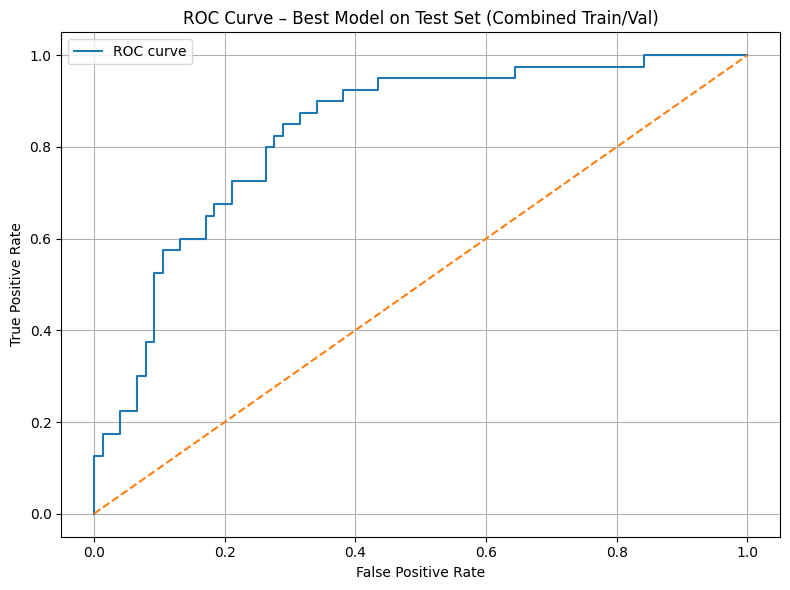

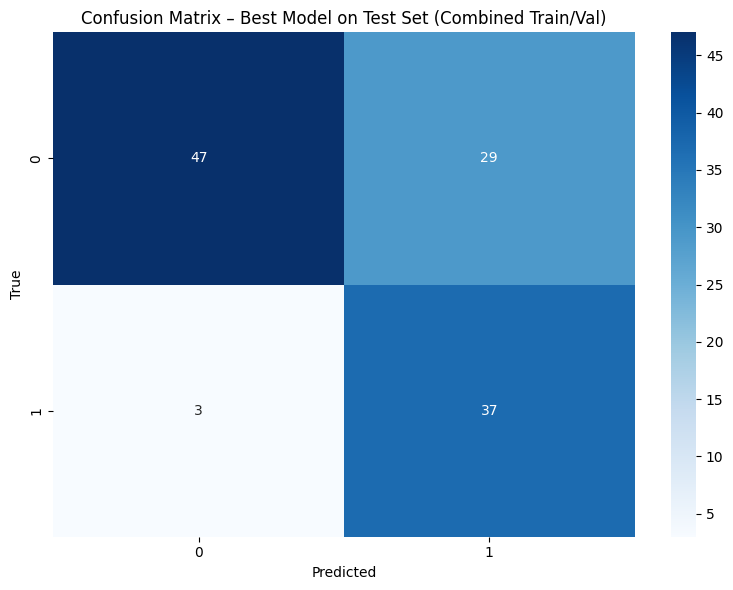


Final Performance measures for the best model on the test set:



,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Best Model on Test Set (Combined Train/Val),0.7241,0.5606,0.9250,0.6184,0.6981,0.8326


In [24]:
# Combine training and validation datasets used for hyperparameters tuning
X_train_tot = pd.concat([X_train, X_val], ignore_index=True)
y_train_tot = pd.concat([y_train, y_val], ignore_index=True)

# Retrieve the best parameters
best_params = bt.params
best_threshold = best_params['classification_threshold']

# Instantiate KerasClassifier with the create_model function and best parameters
final_model = KerasClassifier(
    model=create_model,
    model__n_layers=best_params['n_layers'],
    model__units_1=best_params['units_1'],
    model__units_2=best_params.get('units_2'),
    model__units_3=best_params.get('units_3'),
    model__learning_rate=best_params['learning_rate'],
    model__batch_norm=best_params['batch_norm'],
    model__dropout_rate=best_params['dropout_rate'],
    model__l2_reg=best_params['l2_reg'],
    model__optimizer=best_params['optimizer'],
    batch_size=best_params['batch_size'],
    epochs=best_params['epochs'],
    verbose=0
)

# Recreate and fit the pipeline with the best model wrapper on the combined data
# The scaler is refitted on the combined training data
final_pipeline = Pipeline([('scaler', StandardScaler()), ('nn', final_model)])
print("Fitting the final best model...")
final_pipeline.fit(X_train_tot, y_train_tot)
print("Fitting complete.")

# Scale the test data using the scaler fitted on the combined data
X_test_scaled = final_pipeline.named_steps['scaler'].transform(X_test)

# Make predictions on the scaled test set using the fitted Keras model
# We extract the Keras model from the pipeline wrapper
fitted_final_model = final_pipeline.named_steps['nn'].model_
y_test_proba = fitted_final_model.predict(X_test_scaled)

# We use the best threshold to predict the target value
y_test_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n we use the best threshold to predict the target value ({best_threshold:.4f})...\n")
df_test_metrics = EvaluateModel(y_test_pred, y_test_proba, y_test, model_name="Best Model on Test Set (Combined Train/Val)")
print("\nFinal Performance measures for the best model on the test set:\n")
display(df_test_metrics.style.format({col: "{:.4f}" for col in df_test_metrics.columns if col != 'Model'}))

In [25]:
#we get information about the layers of the best model
best_model_layers_summary = summarize_layers(fitted_final_model, model_name="Best Optuna Model")
model_summary_df = summarize_model(fitted_final_model, name="Best Optuna Model Summary")

# Display the layer summary DataFrame
print("\nSummary of the Best Optuna Model Layers:\n")
display(best_model_layers_summary)

# Display the model summary DataFrame
print("\nSummary of the Best Optuna Model:\n")
display(model_summary_df)



Summary of the Best Optuna Model Layers:



,Model Name,Layer Name,Layer Type,Output Shape,Activation,Units/Filters,Params,Trainable,Momentum,Epsilon,Dropout Rate
0,Best Optuna Model,dense_263,Dense,N/A,relu,8,72,True,NaN,NaN,NaN
1,Best Optuna Model,batch_normalization_127,BatchNormalization,N/A,N/A,N/A,32,True,0.99,0.001,NaN
2,Best Optuna Model,dropout_143,Dropout,N/A,N/A,N/A,0,True,NaN,NaN,0.121392
3,Best Optuna Model,dense_264,Dense,N/A,sigmoid,1,9,True,NaN,NaN,NaN



Summary of the Best Optuna Model:



,Model,Layers,Neurons,Total Params,Trainable Params,Non-Trainable Params
0,Best Optuna Model Summary,2,9,113,97,16


In [26]:
# End timing and format in hours, minutes, seconds
end_time = time.time()
elapsed_time = end_time - start_time
hours, remainder = divmod(elapsed_time, 3600)
minutes, seconds = divmod(remainder, 60)
print(f"Execution time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

Execution time: 0h 25m 19.94s
